The dataset provided by Invistico Airlines contains valuable information about their customers' experiences and satisfaction levels. With the aim of predicting future customer satisfaction and improving service quality, this dataset encompasses various customer attributes and feedback on different aspects of their flights. The primary objectives of this dataset are to predict customer satisfaction and identify areas for service improvement.

Understanding the variables
satisfaction: The overall satisfaction level of the customer. It is a categorical variable with options "satisfied" or "dissatisfied".

Gender: The gender of the customer. It is a categorical variable with options "male" or "female".

Customer Type: Whether the customer is a "loyal customer" or a "disloyal customer".

Age: The age of the customer.
Type of Travel: The type of travel, such as "Personal Travel" or "Business travel."Class: The class of travel, such as "Eco" or "Business."

Class: The class of travel, such as "Eco" or "Business."

Flight Distance: The distance of the flight.

Seat comfort: Customer rating of seat comfort.

Departure/Arrival time convenient: Customer rating of convenience of departure/arrival times.

Food and drink: Customer rating of food and drink quality.

Gate location: Customer rating of gate location.

Inflight wifi service: Customer rating of inflight Wi-Fi service.

Inflight entertainment: Customer rating of inflight entertainment options.

Online support: Customer rating of online customer support.
Ease of Online booking: Customer rating of ease of online booking.

On-board service: Customer rating of on-board service provided by the airline.

Leg room service: Customer rating of leg room service provided during the flight.

Baggage handling: Customer rating of baggage handling.

Checkin service: Customer rating of check-in service.

Cleanliness: Customer rating of cabin cleanliness.

Online boarding: Customer rating of online boarding process.

Departure Delay in Minutes: The departure delay in minutes for each flight.

Arrival Delay in Minutes: The arrival delay in minutes for each flight.

All rating features measured on a scale from 0 to 5, where higher values indicate greatersatisfaction.

# Load libraries

In [ ]:
# Import libraries. begin, let's import the necessary libraries that we'll be using throughout this notebook:

# Data Manipulation Libraries
import numpy as np
import pandas as pd
# Data Visualization Libraries
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.gridspec as gridspec
import seaborn as sns
# Machine Learning Libraries
from category_encoders import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# Machine Learning Models
import os
import warnings
warnings.filterwarnings('ignore')




In [ ]:
os.getcwd()

'C:\\Users\\dhamija'

In [ ]:
# Reading the data
data = pd.read_csv(r'D:\airlines\train.csv')
data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
data.shape

(103904, 25)

In [ ]:
data.dtypes

Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

In [ ]:
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(" ", "_")
data.columns

Index(['unnamed:_0', 'id', 'gender', 'customer_type', 'age', 'type_of_travel',
       'class', 'flight_distance', 'inflight_wifi_service',
       'departure/arrival_time_convenient', 'ease_of_online_booking',
       'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
       'inflight_entertainment', 'on-board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'inflight_service',
       'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'satisfaction'],
      dtype='object')

In [ ]:
# Remove index and ID columns as they don't contribute to analysis
data.drop(columns=['unnamed:_0', 'id'], inplace=True)
num_cols = data.select_dtypes(include=['int64', 'float64'])

In [ ]:
# Calculate and display missing value percentages
print("\n--- Missing Data Percentages ---")
print((data.isnull().sum() / len(data)) * 100)


--- Missing Data Percentages ---
gender                               0.000000
customer_type                        0.000000
age                                  0.000000
type_of_travel                       0.000000
class                                0.000000
flight_distance                      0.000000
inflight_wifi_service                0.000000
departure/arrival_time_convenient    0.000000
ease_of_online_booking               0.000000
gate_location                        0.000000
food_and_drink                       0.000000
online_boarding                      0.000000
seat_comfort                         0.000000
inflight_entertainment               0.000000
on-board_service                     0.000000
leg_room_service                     0.000000
baggage_handling                     0.000000
checkin_service                      0.000000
inflight_service                     0.000000
cleanliness                          0.000000
departure_delay_in_minutes           0.000000


In [ ]:
column = ['arrival_delay_in_minutes']
data = data.dropna(subset=column)

In [ ]:
data.isnull().sum()

gender                               0
customer_type                        0
age                                  0
type_of_travel                       0
class                                0
flight_distance                      0
inflight_wifi_service                0
departure/arrival_time_convenient    0
ease_of_online_booking               0
gate_location                        0
food_and_drink                       0
online_boarding                      0
seat_comfort                         0
inflight_entertainment               0
on-board_service                     0
leg_room_service                     0
baggage_handling                     0
checkin_service                      0
inflight_service                     0
cleanliness                          0
departure_delay_in_minutes           0
arrival_delay_in_minutes             0
satisfaction                         0
dtype: int64

In [ ]:
# check if duplicated in data

data.duplicated().any()

np.False_

In [ ]:
data.describe()

,age,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes
count,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000
mean,39.380466,1189.325202,2.729753,3.060081,2.756984,2.977026,3.202126,3.250497,3.439765,3.358341,3.382609,3.351401,3.631687,3.304323,3.640761,3.286397,14.747939,15.178678
std,15.113125,997.297235,1.327866,1.525233,1.398934,1.277723,1.329401,1.349433,1.318896,1.333030,1.288284,1.315409,1.181051,1.265396,1.175603,1.312194,38.116737,38.698682
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,842.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
# see quick info of category values 

data.describe(include = object)

,gender,customer_type,type_of_travel,class,satisfaction
count,103594,103594,103594,103594,103594
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,52576,84662,71465,49533,58697


###Boxplot of all columns to see outliers
data.plot(kind='box',subplots=True,layout=(5,5),figsize=(40,60))
plt.show()

In [ ]:
# Calculate bounds for Flight_Distance
a = np.percentile(data["flight_distance"], 25)
b = np.percentile(data["flight_distance"], 75)
iqr = b - a
upper_bound = b + (1.5 * iqr)
lower_bound = a- (1.5 * iqr)
print("range is:")
print("[", lower_bound, ",", upper_bound, "]")



range is:
[ -1579.5 , 3736.5 ]


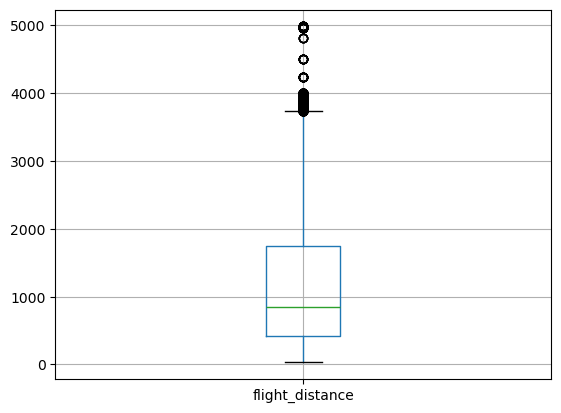

In [ ]:
data.boxplot('flight_distance')
plt.show()

In [ ]:
data = data[data['flight_distance'] < 3000]

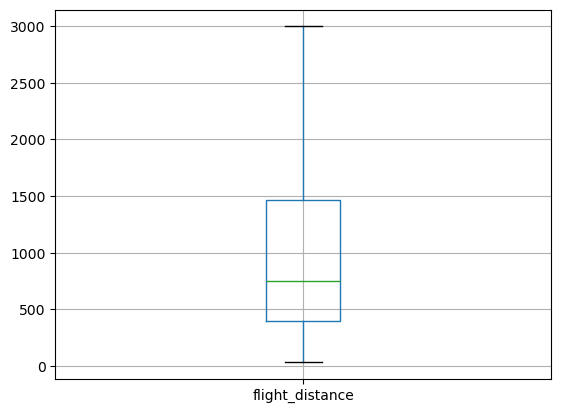

In [ ]:
data.boxplot('flight_distance')
plt.show()

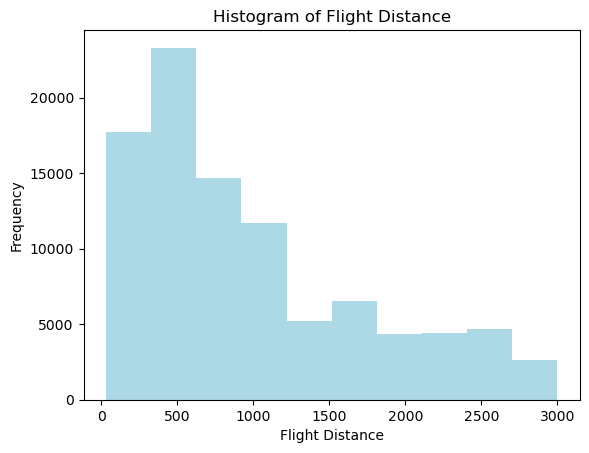

In [ ]:
# Histogram for Flight Distance

plt.hist(data['flight_distance'], color='lightblue')
plt.title('Histogram of Flight Distance')
plt.xlabel('Flight Distance')
plt.ylabel('Frequency')
plt.show()

data visualization

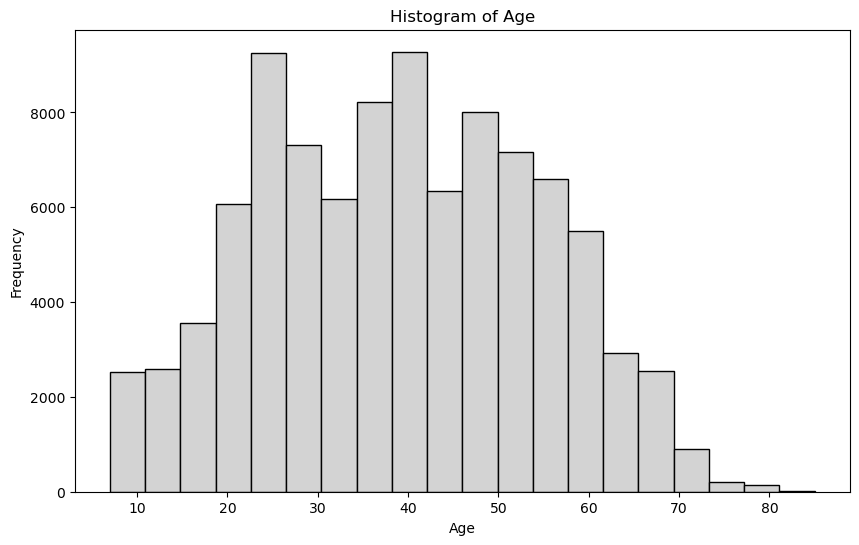

In [ ]:
# Histogram for Age
plt.figure(figsize=(10, 6))
plt.hist(data['age'], bins=20, color='lightgrey', edgecolor='black')
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
data['satisfaction'].value_counts()

satisfaction
neutral or dissatisfied    56831
satisfied                  38507
Name: count, dtype: int64

In [ ]:
#data["satisfaction"].replace("satisfied",0,inplace=True)
#data["satisfaction"].replace("neutral or dissatisfied",1,inplace=True)

In [ ]:
#data['satisfaction'].value_counts()

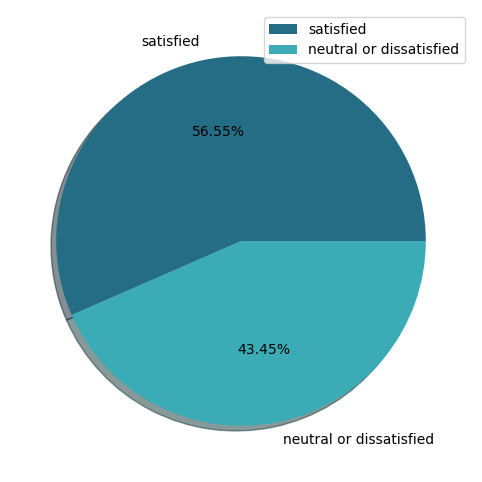

In [ ]:
plt.figure(figsize=(10, 6))
data_pie  = [73452 , 56428]
labels = ["satisfied", "neutral or dissatisfied"]

plt.pie(data_pie ,labels= labels  , autopct="%1.2f%%", shadow= True, colors= ['#256D85', '#3BACB6'])
plt.legend()
plt.show()

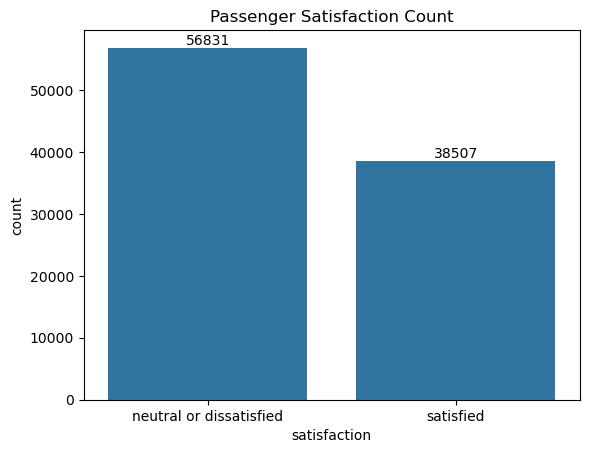

In [ ]:

ax = sns.countplot(x='satisfaction', data=data)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Passenger Satisfaction Count")
plt.show()

In [ ]:
data['gender'].value_counts()

gender
Female    48438
Male      46900
Name: count, dtype: int64

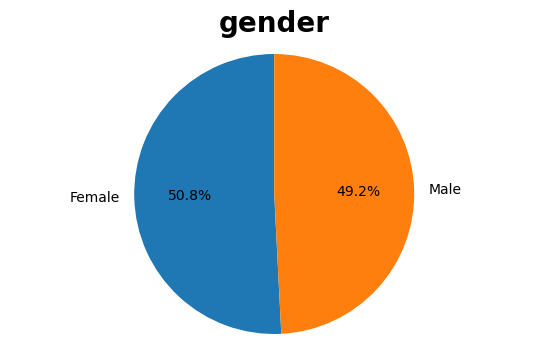

In [ ]:


# Setting up the figure size
fig = plt.figure(figsize=(15, 4))
grid = gridspec.GridSpec(nrows=1, ncols=2, figure=fig)

# Adding the subplot (the image shows index 0,1)
ax3 = fig.add_subplot(grid[0, 1])

# Setting the title with bold font
ax3.set_title("gender", weight="bold", fontsize=20)

# Extracting labels and values from the dataframe
label = list(data["gender"].value_counts().index)
value = list(data["gender"].value_counts().values)

# Creating the pie chart
# explode=(0, 0.1) pulls the second slice out slightly for emphasis
ax3.pie(value, labels=label, autopct="%1.1f%%",  startangle=90)

# Ensuring the pie is drawn as a circle
ax3.axis("equal")

# Display the plot
plt.show()

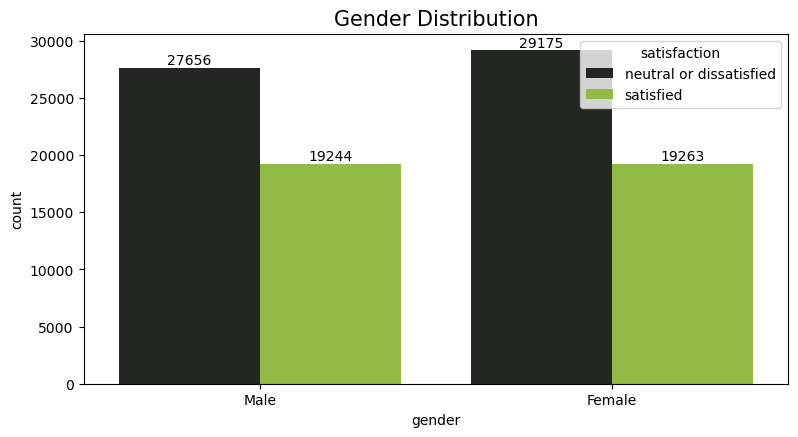

In [ ]:
# Create the figure and grid layout
fig = plt.figure(figsize=(20, 10))
grid = gridspec.GridSpec(nrows=2, ncols=2, figure=fig)

# Add the subplot at the specific grid location
ax1 = fig.add_subplot(grid[0, :1])
ax1.set_title("Gender Distribution", fontsize=15)

# Generate the countplot with 'Gender' on x-axis and 'satisfaction' as hue
sns.countplot(x=data["gender"], hue=data["satisfaction"], ax=ax1, color="yellowgreen")

# Loop through containers to add bar labels (showing the count on top of each bar)
for bars in ax1.containers:
    ax1.bar_label(bars)

plt.show()    

In [ ]:

data['class'].value_counts()

class
Eco         46545
Business    41337
Eco Plus     7456
Name: count, dtype: int64

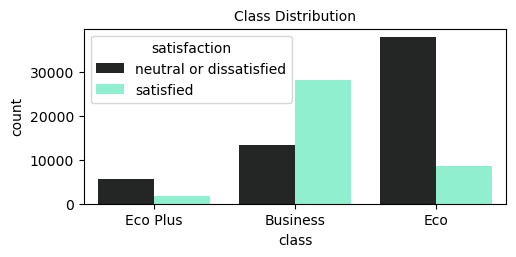

In [ ]:
# Define the figure size
fig = plt.figure(figsize=(12, 5))

# Add the subplot using the grid defined in previous steps
# This places it in the first row, second column area
ax2 = fig.add_subplot(grid[0, :1])

# Set the title for the specific axis
ax2.set_title("Class Distribution", fontsize=10)

# Create the countplot
# 'Class' is the x-axis, 'satisfaction' is the legend/hue
sns.countplot(x=data["class"], hue=data["satisfaction"], ax=ax2, color="aquamarine")

# Display the final plot
plt.show()

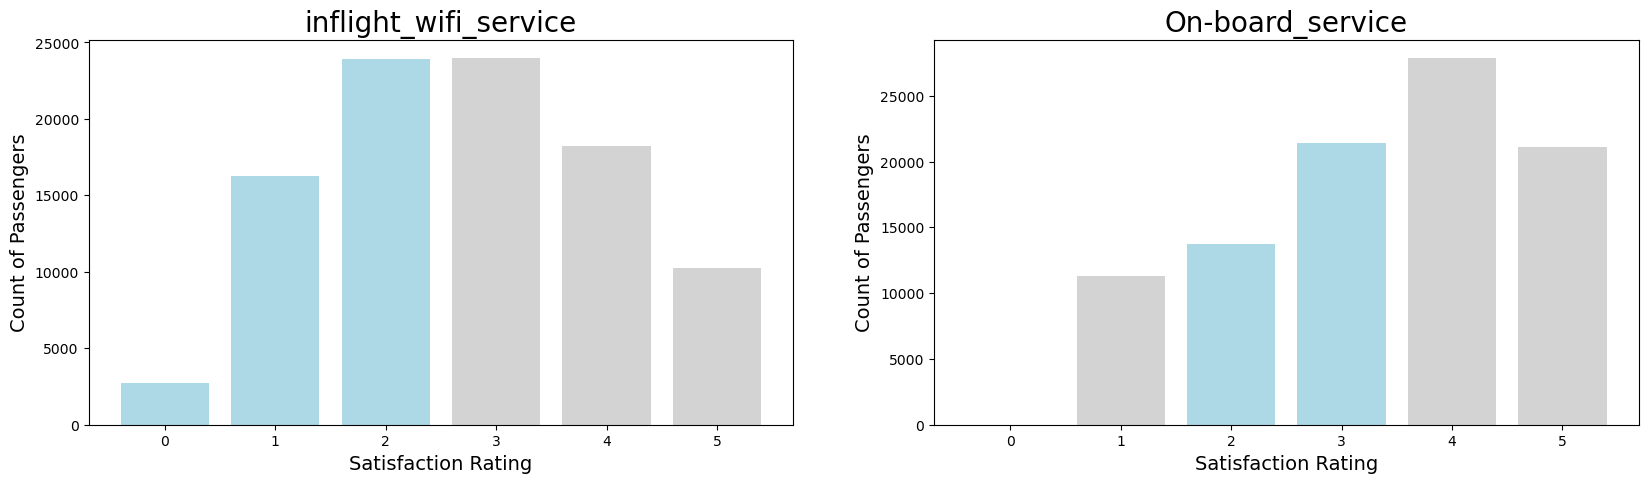

In [ ]:
# Create subplots: 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

# plot 1
ax1.bar(data["inflight_wifi_service"].value_counts().index, data["inflight_wifi_service"].value_counts(), color=["lightgrey", "lightblue"])
ax1.set_title("inflight_wifi_service", fontsize=20)
ax1.set_xlabel("Satisfaction Rating", fontsize=14)
ax1.set_ylabel("Count of Passengers", fontsize=14)

# plot 2
ax2.bar(data["on-board_service"].value_counts().index, data["on-board_service"].value_counts(), color=["lightgrey", "lightblue"])
ax2.set_title("On-board_service", fontsize=20)
ax2.set_xlabel("Satisfaction Rating", fontsize=14)
ax2.set_ylabel("Count of Passengers", fontsize=14)


plt.show()

In [ ]:
data['inflight_wifi_service'].value_counts()

inflight_wifi_service
3    23981
2    23904
4    18208
1    16256
5    10259
0     2730
Name: count, dtype: int64

In [ ]:
data['on-board_service'].value_counts()

on-board_service
4    27863
3    21382
5    21123
2    13701
1    11267
0        2
Name: count, dtype: int64

In [ ]:
# Identifying numerical and categorical variables
numerical_variables = ['age', 'flight_distance', 'departure_delay_in_minutes', 'arrival_delay_in_minutes']

# Define the full list of categorical variables to be plotted
categorical_variables = [
    'inflight_wifi_service', 'on-board_service', 'leg_room_service',
    'ease_of_online_booking', 'inflight_wifi_service', 'seat_comfort',
    'food_and_drink', 'inflight_service', 'checkin_service',
    'cleanliness', 'customer_type', 'satisfaction',
    'baggage_handling', 'class', 'gate_location',
    'departure/arrival_time_convenient', 'type_of_travel',
    'online_boarding', 'gender'
]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95338 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             95338 non-null  object 
 1   customer_type                      95338 non-null  object 
 2   age                                95338 non-null  int64  
 3   type_of_travel                     95338 non-null  object 
 4   class                              95338 non-null  object 
 5   flight_distance                    95338 non-null  int64  
 6   inflight_wifi_service              95338 non-null  int64  
 7   departure/arrival_time_convenient  95338 non-null  int64  
 8   ease_of_online_booking             95338 non-null  int64  
 9   gate_location                      95338 non-null  int64  
 10  food_and_drink                     95338 non-null  int64  
 11  online_boarding                    95338 non-null  int64  

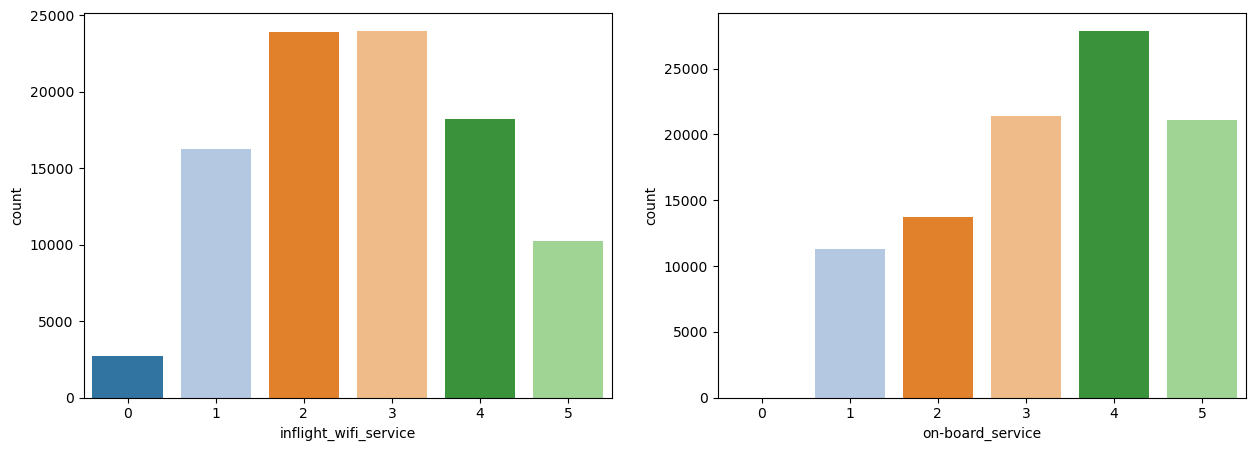

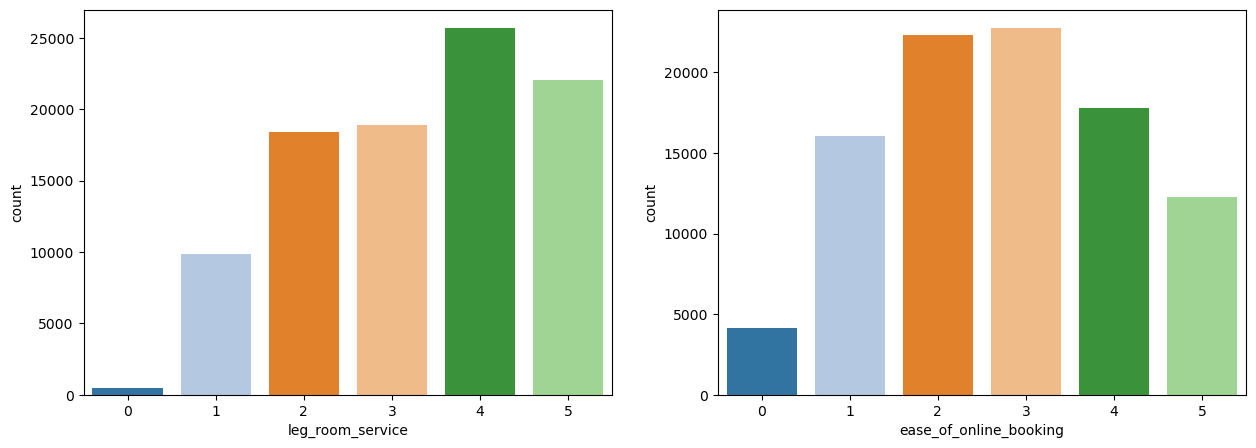

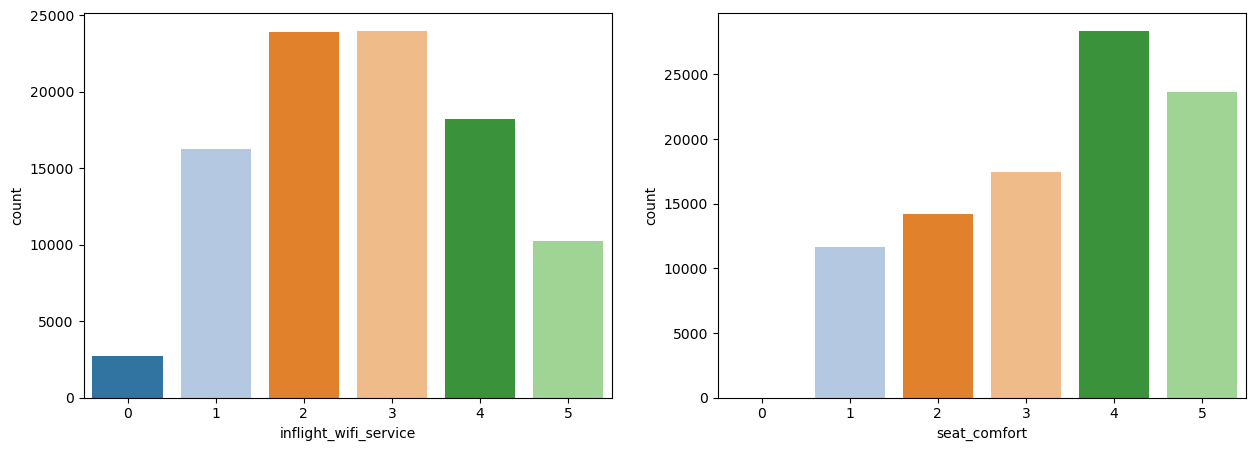

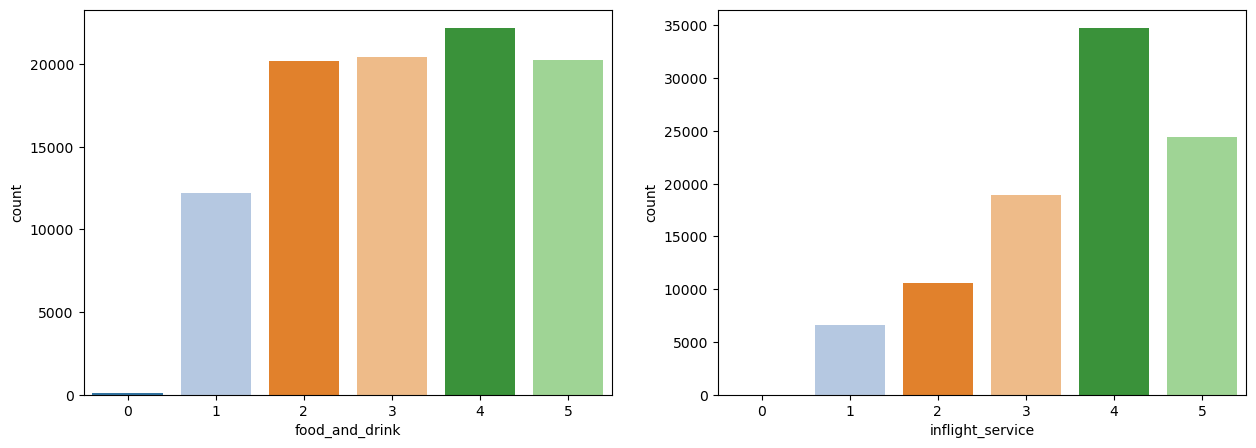

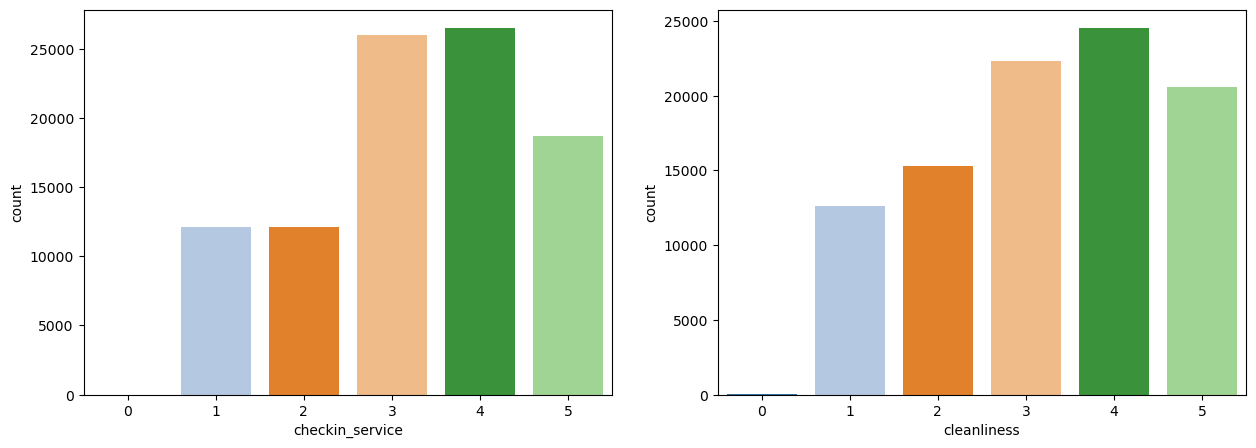

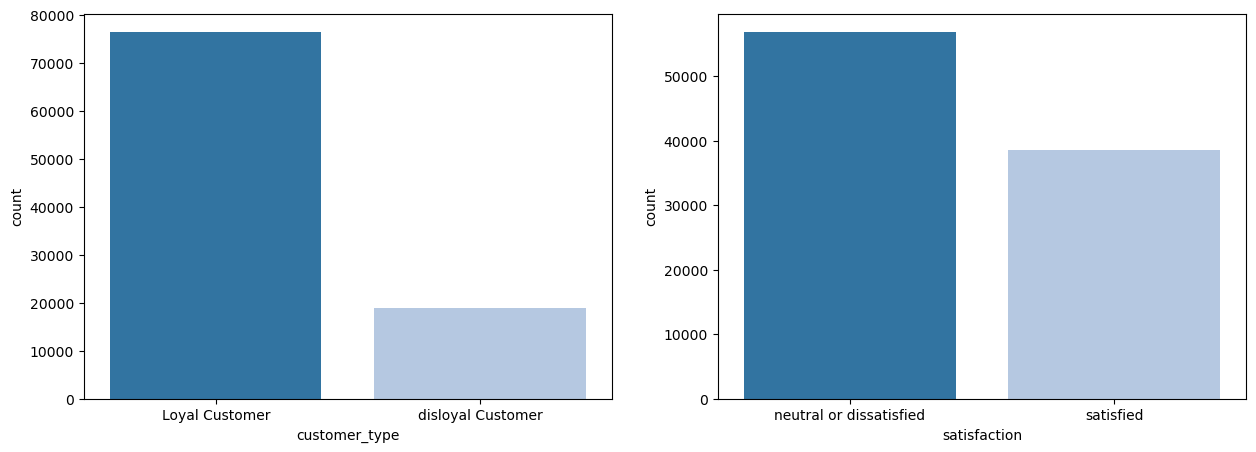

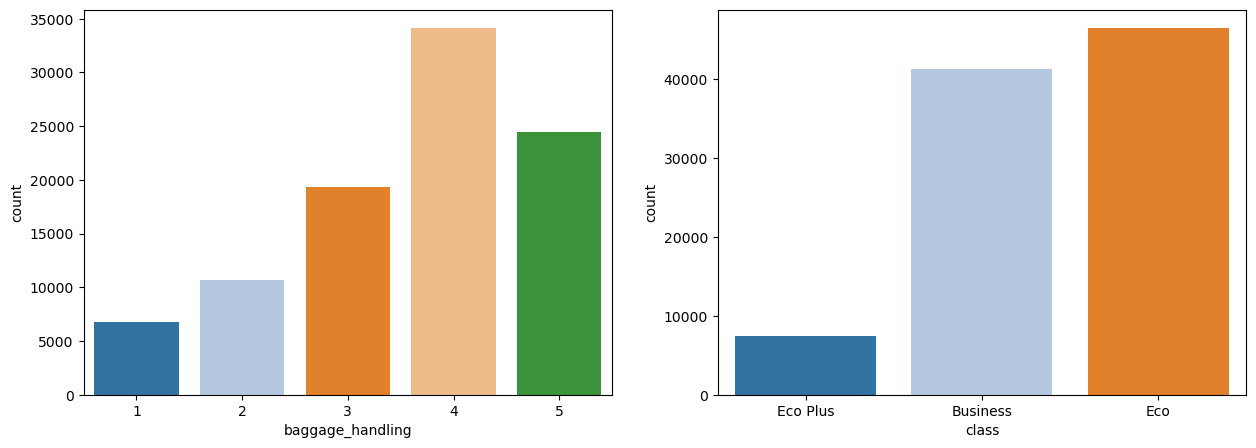

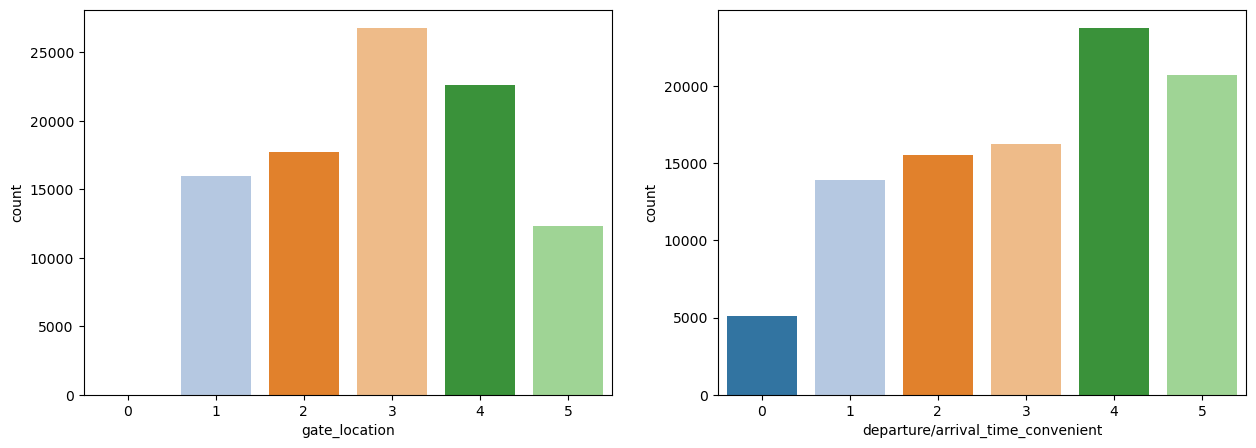

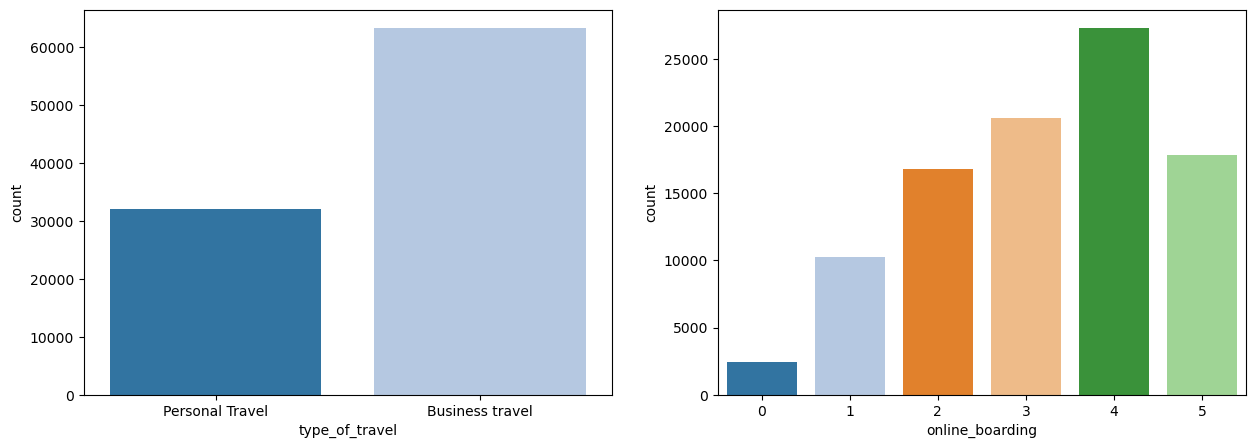

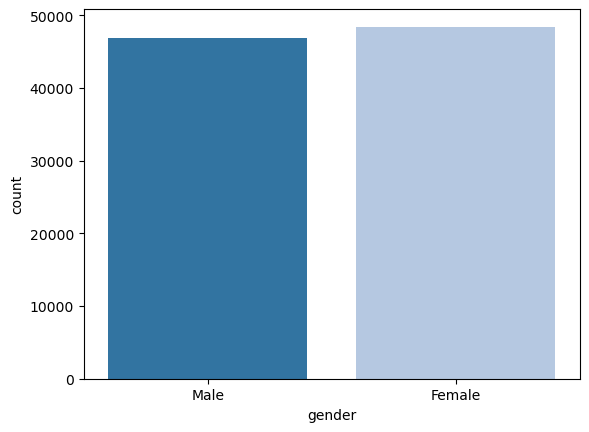

In [ ]:


# Loop through the list, stepping by 2 to create pairs
for i in range(0, len(categorical_variables), 2):
    # Convert first variable in pair to object type to ensure proper plotting
    data[categorical_variables[i]] = data[categorical_variables[i]].astype('object')
    
    # Check if there is only one variable left (odd number in list)
    if i + 1 == len(categorical_variables):
        sns.countplot(x=data[categorical_variables[i]], palette='tab20')
        plt.show()
    
    # Otherwise, plot the pair side-by-side
    else:
        # Convert second variable in pair to object type
        data[categorical_variables[i+1]] = data[categorical_variables[i+1]].astype('object')
        
        # Create a figure with two subplots side-by-side
        figure, axis = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
        
        # Plot first variable on the left (axis 0)
        sns.countplot(ax=axis[0], x=data[categorical_variables[i]], palette='tab20')
        
        # Plot second variable on the right (axis 1)
        sns.countplot(ax=axis[1], x=data[categorical_variables[i+1]], palette='tab20')
        
        plt.show()

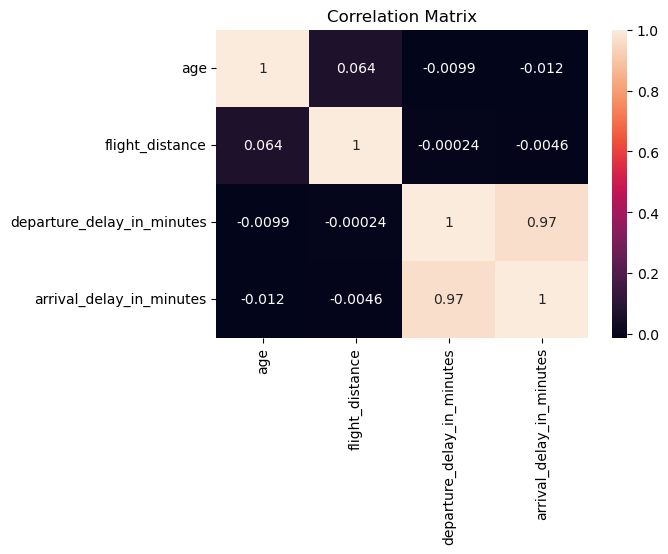

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(data[numerical_variables].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

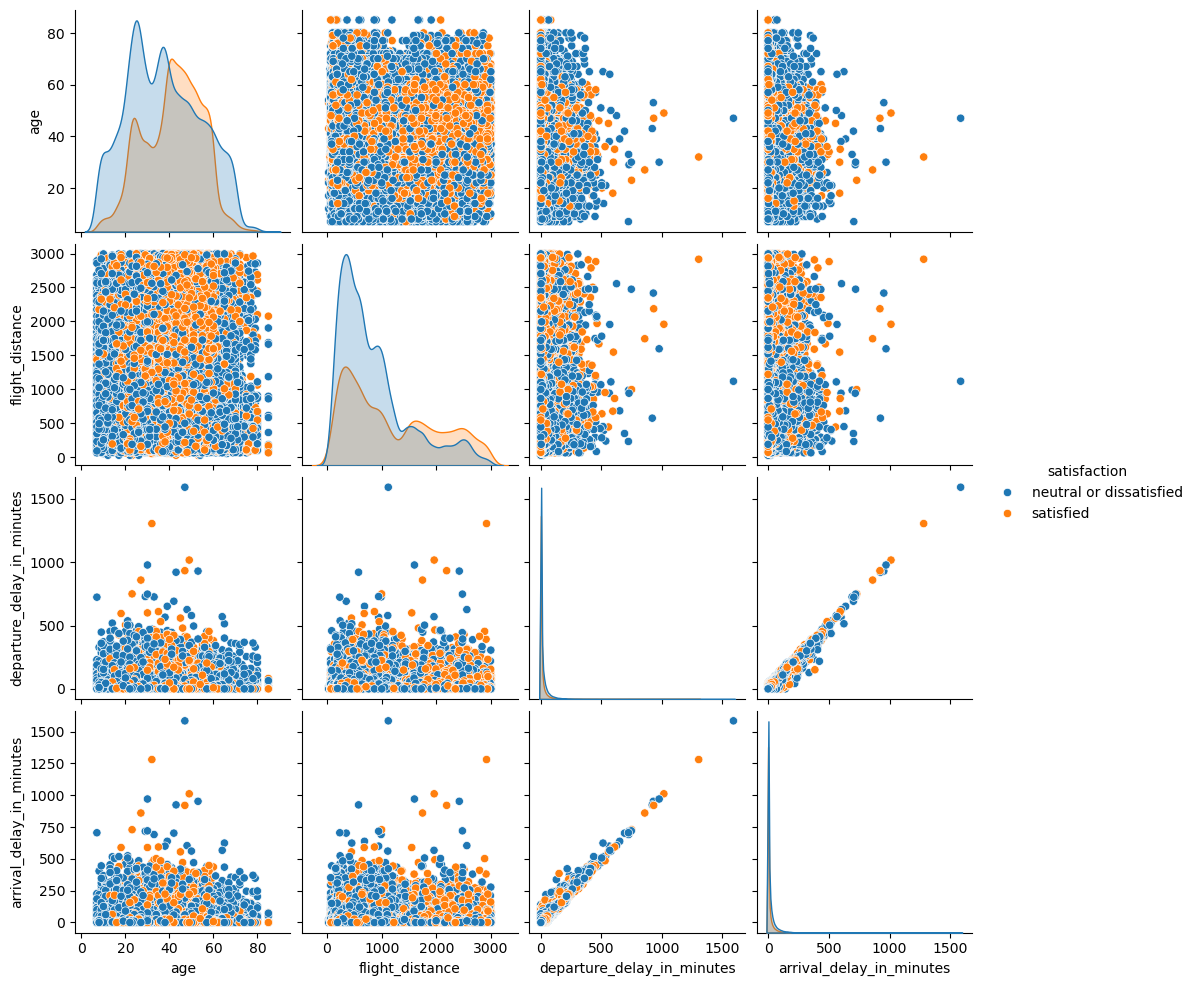

In [ ]:
# 1. Create the subset
temp_df = data[['age', 'flight_distance', 'departure_delay_in_minutes', 'arrival_delay_in_minutes', 'satisfaction']]

# 2. Pass the subset directly into the pairplot
sns.pairplot(temp_df, hue="satisfaction", palette='tab10')

# 3. Display
plt.show()

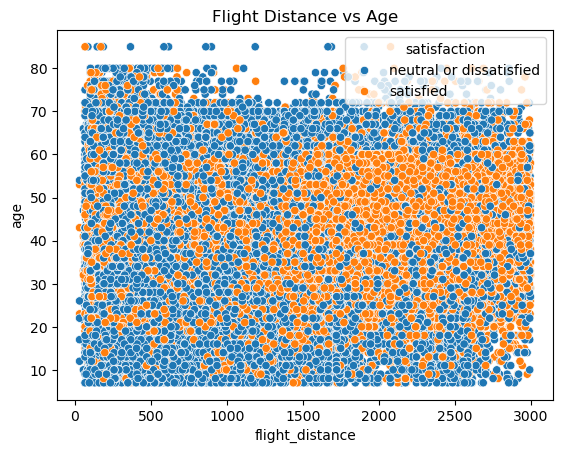

In [ ]:
sns.scatterplot(x='flight_distance', y='age', hue='satisfaction', data=data)
plt.title("Flight Distance vs Age")
plt.show()

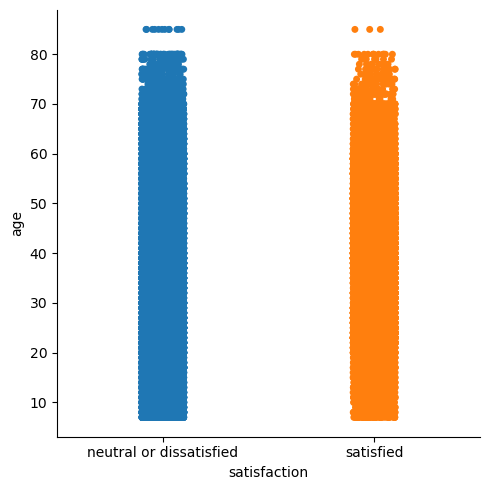

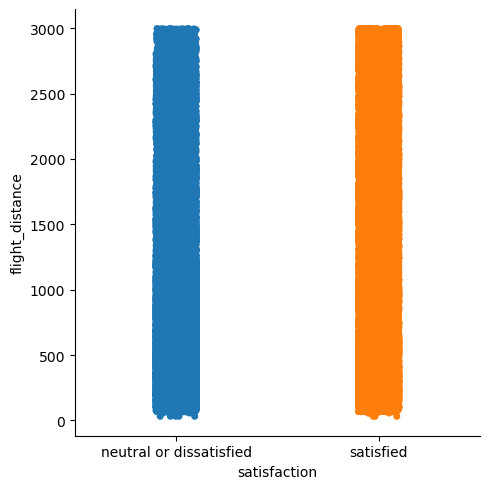

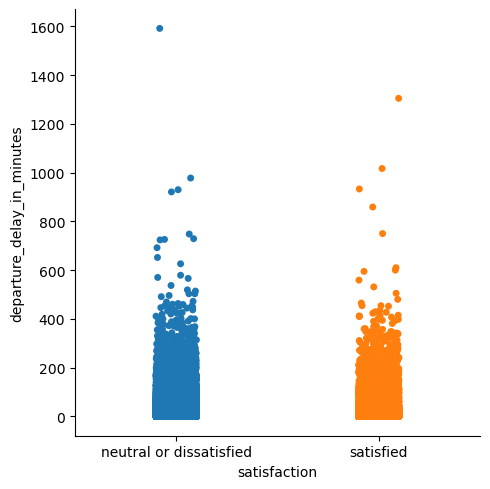

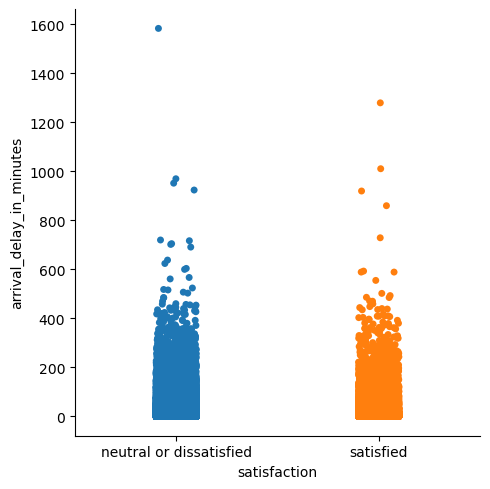

In [ ]:
for i in numerical_variables:
    sns.catplot(x='satisfaction', y=i, data=data, palette='tab10')
    
    plt.show()

In [ ]:
# Dropping the highly correlated column Arrival_Delay_in_Minutes
data.drop(labels=["arrival_delay_in_minutes"], axis=1 ,inplace=True)

# Updating the list of numerical variables
numerical_variables.remove("arrival_delay_in_minutes")

In [ ]:
# Convert the list to a 'set' and back to a 'list' to remove any duplicates
categorical_variables = list(set(categorical_variables))

In [ ]:
# 1. Define the list logic first
valid_categorical = [col for col in categorical_variables if col in data.columns]



In [ ]:
print(f"Columns to encode: {valid_categorical}")
print(data[valid_categorical].dtypes)

Columns to encode: ['satisfaction', 'departure/arrival_time_convenient', 'ease_of_online_booking', 'on-board_service', 'gate_location', 'baggage_handling', 'leg_room_service', 'online_boarding', 'seat_comfort', 'inflight_service', 'gender', 'food_and_drink', 'class', 'inflight_wifi_service', 'customer_type', 'checkin_service', 'type_of_travel', 'cleanliness']
satisfaction                         object
departure/arrival_time_convenient    object
ease_of_online_booking               object
on-board_service                     object
gate_location                        object
baggage_handling                     object
leg_room_service                     object
online_boarding                      object
seat_comfort                         object
inflight_service                     object
gender                               object
food_and_drink                       object
class                                object
inflight_wifi_service                object
customer_type         

In [ ]:


if not valid_categorical:
    print("Warning: No valid categorical columns found to encode!")
    data_one_hot = data.copy() # Just copy the data if nothing to encode
else:
    from category_encoders import OneHotEncoder
    encoder = OneHotEncoder(cols=valid_categorical, use_cat_names=True)
    data_one_hot = encoder.fit_transform(data)


data_one_hot.columns

Index(['gender_Male', 'gender_Female', 'customer_type_Loyal Customer',
       'customer_type_disloyal Customer', 'age',
       'type_of_travel_Personal Travel', 'type_of_travel_Business travel',
       'class_Eco Plus', 'class_Business', 'class_Eco', 'flight_distance',
       'inflight_wifi_service_3.0', 'inflight_wifi_service_2.0',
       'inflight_wifi_service_4.0', 'inflight_wifi_service_1.0',
       'inflight_wifi_service_5.0', 'inflight_wifi_service_0.0',
       'departure/arrival_time_convenient_4.0',
       'departure/arrival_time_convenient_2.0',
       'departure/arrival_time_convenient_5.0',
       'departure/arrival_time_convenient_3.0',
       'departure/arrival_time_convenient_1.0',
       'departure/arrival_time_convenient_0.0', 'ease_of_online_booking_3.0',
       'ease_of_online_booking_2.0', 'ease_of_online_booking_5.0',
       'ease_of_online_booking_4.0', 'ease_of_online_booking_1.0',
       'ease_of_online_booking_0.0', 'gate_location_1.0', 'gate_location_3.0',
    

In [ ]:
# Dropping redundant or negatively correlated binary columns
data_one_hot.drop(labels=['gender_Male', 'customer_type_Loyal Customer', 'type_of_travel_Personal Travel'], axis=1,inplace=True)

# Preview the processed dataframe
data_one_hot.head()

,gender_Female,customer_type_disloyal Customer,age,type_of_travel_Business travel,class_Eco Plus,class_Business,class_Eco,flight_distance,inflight_wifi_service_3.0,inflight_wifi_service_2.0,...,inflight_service_0.0,cleanliness_5.0,cleanliness_1.0,cleanliness_2.0,cleanliness_3.0,cleanliness_4.0,cleanliness_0.0,departure_delay_in_minutes,satisfaction_neutral or dissatisfied,satisfaction_satisfied
0,0,0,13,0,1,0,0,460,1,0,...,0,1,0,0,0,0,0,25,1,0
1,0,1,25,1,0,1,0,235,1,0,...,0,0,1,0,0,0,0,1,1,0
2,1,0,26,1,0,1,0,1142,0,1,...,0,1,0,0,0,0,0,0,0,1
3,1,0,25,1,0,1,0,562,0,1,...,0,0,0,1,0,0,0,11,1,0
4,0,0,61,1,0,1,0,214,1,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
transformer = MinMaxScaler()

# Define the columns to be scaled
# Make sure 'numerical_variables' contains the correct column names
# (e.g., ['age', 'flight_distance', 'departure_delay_in_minutes'])

# Apply scaling to all numerical variables at once
data_one_hot[numerical_variables] = transformer.fit_transform(data_one_hot[numerical_variables])

# Preview the scaled data
data_one_hot.head()

,gender_Female,customer_type_disloyal Customer,age,type_of_travel_Business travel,class_Eco Plus,class_Business,class_Eco,flight_distance,inflight_wifi_service_3.0,inflight_wifi_service_2.0,...,inflight_service_0.0,cleanliness_5.0,cleanliness_1.0,cleanliness_2.0,cleanliness_3.0,cleanliness_4.0,cleanliness_0.0,departure_delay_in_minutes,satisfaction_neutral or dissatisfied,satisfaction_satisfied
0,0,0,0.076923,0,1,0,0,0.144542,1,0,...,0,1,0,0,0,0,0,0.015704,1,0
1,0,1,0.230769,1,0,1,0,0.068733,1,0,...,0,0,1,0,0,0,0,0.000628,1,0
2,1,0,0.243590,1,0,1,0,0.374326,0,1,...,0,1,0,0,0,0,0,0.000000,0,1
3,1,0,0.230769,1,0,1,0,0.178908,0,1,...,0,0,0,1,0,0,0,0.006910,1,0
4,0,0,0.692308,1,0,1,0,0.061658,1,0,...,0,0,0,0,1,0,0,0.000000,0,1


In [ ]:
print(data_one_hot.columns.tolist())

['gender_Female', 'customer_type_disloyal Customer', 'age', 'type_of_travel_Business travel', 'class_Eco Plus', 'class_Business', 'class_Eco', 'flight_distance', 'inflight_wifi_service_3.0', 'inflight_wifi_service_2.0', 'inflight_wifi_service_4.0', 'inflight_wifi_service_1.0', 'inflight_wifi_service_5.0', 'inflight_wifi_service_0.0', 'departure/arrival_time_convenient_4.0', 'departure/arrival_time_convenient_2.0', 'departure/arrival_time_convenient_5.0', 'departure/arrival_time_convenient_3.0', 'departure/arrival_time_convenient_1.0', 'departure/arrival_time_convenient_0.0', 'ease_of_online_booking_3.0', 'ease_of_online_booking_2.0', 'ease_of_online_booking_5.0', 'ease_of_online_booking_4.0', 'ease_of_online_booking_1.0', 'ease_of_online_booking_0.0', 'gate_location_1.0', 'gate_location_3.0', 'gate_location_2.0', 'gate_location_5.0', 'gate_location_4.0', 'gate_location_0.0', 'food_and_drink_5.0', 'food_and_drink_1.0', 'food_and_drink_2.0', 'food_and_drink_4.0', 'food_and_drink_3.0', 'f

In [ ]:
# 1. Define your target (y)
y = data_one_hot['satisfaction_satisfied']

# 2. Define your features (X) 
# CRITICAL: You must drop BOTH satisfaction-related columns
X = data_one_hot.drop(['satisfaction_satisfied', 'satisfaction_neutral or dissatisfied'], axis=1)

# 3. Re-run the split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.head()

# 4. Now re-run your Random Forest fit and predict cells

,gender_Female,customer_type_disloyal Customer,age,type_of_travel_Business travel,class_Eco Plus,class_Business,class_Eco,flight_distance,inflight_wifi_service_3.0,inflight_wifi_service_2.0,...,inflight_service_1.0,inflight_service_2.0,inflight_service_0.0,cleanliness_5.0,cleanliness_1.0,cleanliness_2.0,cleanliness_3.0,cleanliness_4.0,cleanliness_0.0,departure_delay_in_minutes
24197,0,0,0.192308,0,1,0,0,0.485175,0,0,...,0,0,0,1,0,0,0,0,0,0.000000
64621,1,0,0.269231,1,1,0,0,0.764488,0,0,...,0,0,0,0,1,0,0,0,0,0.000000
38448,1,0,0.230769,1,0,1,0,0.530323,0,1,...,0,0,0,0,0,1,0,0,0,0.005025
57497,1,0,0.038462,0,0,0,1,0.321765,0,0,...,0,0,0,1,0,0,0,0,0,0.000000
86205,0,0,0.628205,1,0,0,1,0.118598,0,1,...,0,0,0,0,1,0,0,0,0,0.000000


In [ ]:
# Preview the training labels
y_train.head()

24197    0
64621    0
38448    0
57497    0
86205    0
Name: satisfaction_satisfied, dtype: int64

******************** LOGISTIC REGRESSION MODEL RESULTS ********************
Accuracy score of testing set: 0.93 

Precision score of testing set: 0.93 

Recall score of testing set: 0.93 

F1 score of testing set: 0.93 



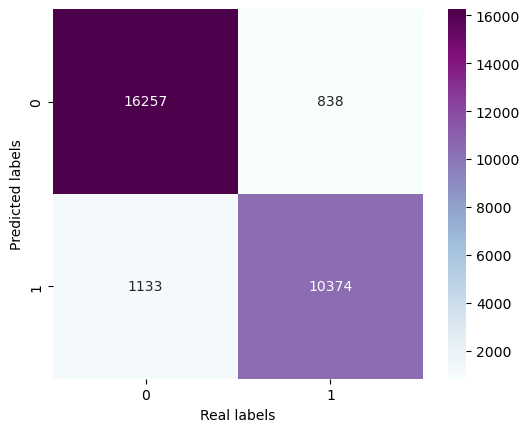

In [ ]:
# Model initialization and training
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

# Evaluation Results
print("\033[1m" + "*" * 20 + " LOGISTIC REGRESSION MODEL RESULTS " + "*" * 20 + "\033[0m")
print('Accuracy score of testing set:', round(accuracy_score(y_test, y_pred_log_reg), 2), '\n')
print('Precision score of testing set:', round(precision_score(y_test, y_pred_log_reg, average="weighted"), 2), '\n')
print('Recall score of testing set:', round(recall_score(y_test, y_pred_log_reg, average="weighted"), 2), '\n')
print('F1 score of testing set:', round(f1_score(y_test, y_pred_log_reg, average="weighted"), 2), '\n')

# Confusion Matrix Heatmap
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(cm_log_reg, annot=True, square=True, fmt='g', cmap='BuPu')
plt.xlabel("Real labels")
plt.ylabel("Predicted labels")
plt.show()

******************** Random Forest Classifier MODEL RESULTS ********************
Accuracy score of testing set: 0.96 

Precision score of testing set: 0.96 

Recall score of testing set: 0.96 

F1 score of testing set: 0.96 



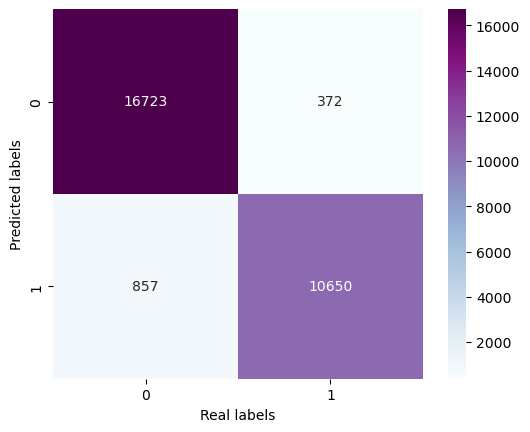

In [ ]:
# Model initialization and training
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

# Evaluation Results
print("\033[1m" + "*" * 20 + " Random Forest Classifier MODEL RESULTS " + "*" * 20 + "\033[0m")
print('Accuracy score of testing set:', round(accuracy_score(y_test, y_pred_rfc), 2), '\n')
print('Precision score of testing set:', round(precision_score(y_test, y_pred_rfc, average="weighted"), 2), '\n')
print('Recall score of testing set:', round(recall_score(y_test, y_pred_rfc, average="weighted"), 2), '\n')
print('F1 score of testing set:', round(f1_score(y_test, y_pred_rfc, average="weighted"), 2), '\n')

# Confusion Matrix Heatmap
cm_rfc = confusion_matrix(y_test, y_pred_rfc)
sns.heatmap(cm_rfc, annot=True, square=True, fmt='g', cmap='BuPu')
plt.xlabel("Real labels")
plt.ylabel("Predicted labels")
plt.show()

******************** Decision Tree Classifier MODEL RESULTS ********************
Accuracy score of testing set: 0.94 

Precision score of testing set: 0.94 

Recall score of testing set: 0.94 

F1 score of testing set: 0.94 



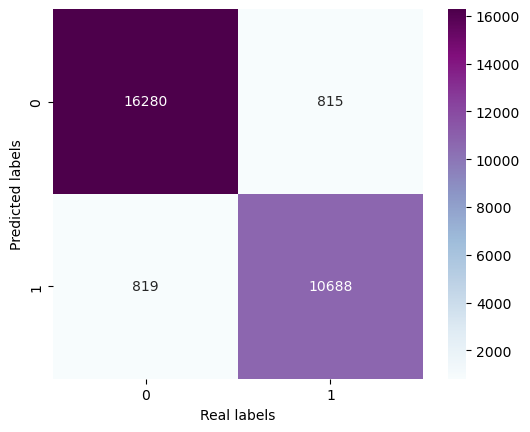

In [ ]:
# Model initialization and training
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred_dt = dtc.predict(X_test)

# Evaluation Results
print("\033[1m" + "*" * 20 + " Decision Tree Classifier MODEL RESULTS " + "*" * 20 + "\033[0m")
print('Accuracy score of testing set:', round(accuracy_score(y_test, y_pred_dt), 2), '\n')
print('Precision score of testing set:', round(precision_score(y_test, y_pred_dt, average="weighted"), 2), '\n')
print('Recall score of testing set:', round(recall_score(y_test, y_pred_dt, average="weighted"), 2), '\n')
print('F1 score of testing set:', round(f1_score(y_test, y_pred_dt, average="weighted"), 2), '\n')

# Confusion Matrix Heatmap
cm_dtc = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dtc, annot=True, square=True, fmt='g', cmap='BuPu')
plt.xlabel("Real labels")
plt.ylabel("Predicted labels")
plt.show()

******************** K Neighbors Classifier MODEL RESULTS ********************
Accuracy score of testing set: 0.93 

Precision score of testing set: 0.93 

Recall score of testing set: 0.93 

F1 score of testing set: 0.93 



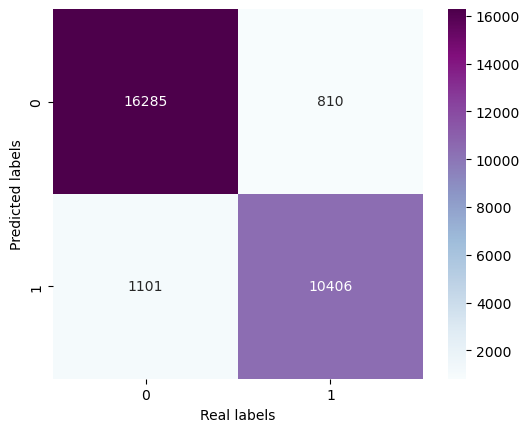

In [ ]:
# Model initialization and training
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Evaluation Results
print("\033[1m" + "*" * 20 + " K Neighbors Classifier MODEL RESULTS " + "*" * 20 + "\033[0m")
print('Accuracy score of testing set:', round(accuracy_score(y_test, y_pred_knn), 2), '\n')
print('Precision score of testing set:', round(precision_score(y_test, y_pred_knn, average="weighted"), 2), '\n')
print('Recall score of testing set:', round(recall_score(y_test, y_pred_knn, average="weighted"), 2), '\n')
print('F1 score of testing set:', round(f1_score(y_test, y_pred_knn, average="weighted"), 2), '\n')

# Confusion Matrix Heatmap
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, square=True, fmt='g', cmap='BuPu')
plt.xlabel("Real labels")
plt.ylabel("Predicted labels")
plt.show()

                   Models   Accuracy
1  RandomForestClassifier  94.825537
2  DecisionTreeClassifier  93.507447
0      LogisticRegression  93.122859
3    KNeighborsClassifier  92.350185


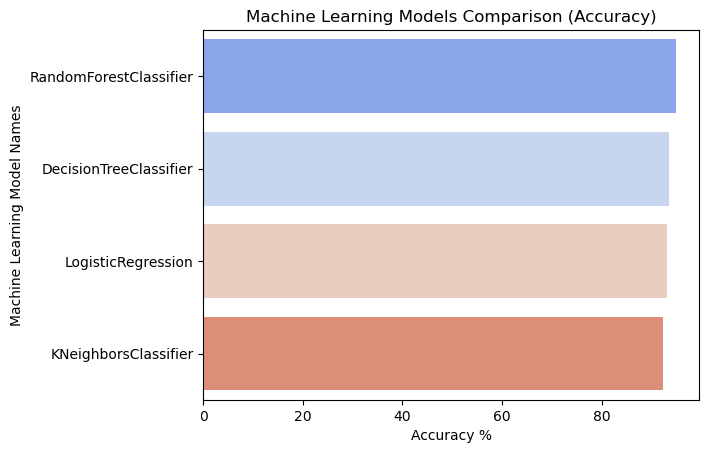

In [ ]:
from sklearn.model_selection import cross_val_score
import pandas as pd

# List of models to evaluate
models = [log_reg, rfc, dtc, knn]

# Initialize an empty DataFrame to store results
results_accuracy = pd.DataFrame(columns=["Models", "Accuracy"])

for model in models:
    # Get the name of the model
    name = model.__class__.__name__
    
    # Perform 3-Fold Cross Validation
    # cv=3 means the data is split into 3 parts
    cv_results = cross_val_score(model, X_test, y_test, cv=3, scoring="accuracy", n_jobs=-1)
    
    # Calculate the mean accuracy and multiply by 100 for percentage
    mean_accuracy = cv_results.mean() * 100
    
    # Create a temporary DataFrame for the current model
    res = pd.DataFrame([[name, mean_accuracy]], columns=["Models", "Accuracy"])
    
    # Append to the main results table
    results_accuracy = pd.concat([results_accuracy, res], ignore_index=True)

# Sort and display results
results_accuracy = results_accuracy.sort_values(by='Accuracy', ascending=False)
print(results_accuracy)

# Plotting the results
sns.barplot(x='Accuracy', y='Models', data=results_accuracy, palette="coolwarm")
plt.xlabel('Accuracy %')
plt.ylabel('Machine Learning Model Names')
plt.title('Machine Learning Models Comparison (Accuracy)')
plt.show()

                   Models   F1 Score
1  RandomForestClassifier  94.786779
2  DecisionTreeClassifier  93.556205
0      LogisticRegression  93.106912
3    KNeighborsClassifier  92.332885


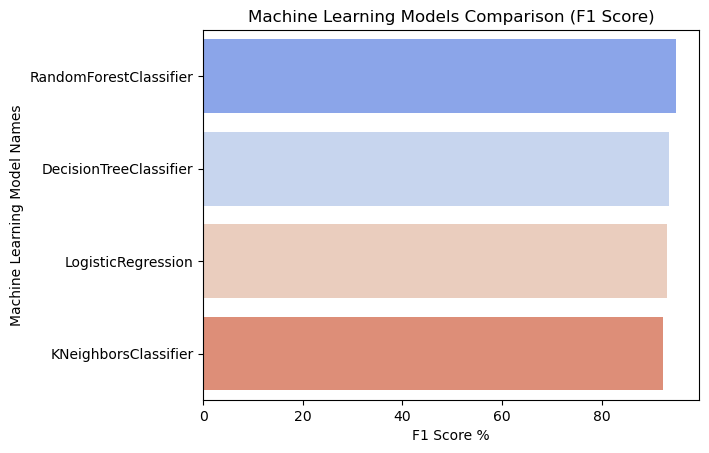

In [ ]:
# Initialize an empty DataFrame for F1 results
results_f1 = pd.DataFrame(columns=["Models", "F1 Score"])

for model in models:
    name = model.__class__.__name__
    
    # Perform 3-Fold Cross Validation using F1 Weighted scoring
    cv_results = cross_val_score(model, X_test, y_test, cv=3, scoring="f1_weighted", n_jobs=-1)
    
    mean_f1 = cv_results.mean() * 100
    res = pd.DataFrame([[name, mean_f1]], columns=["Models", "F1 Score"])
    results_f1 = pd.concat([results_f1, res], ignore_index=True)

# Sort and display results
results_f1 = results_f1.sort_values(by='F1 Score', ascending=False)
print(results_f1)

# Plotting the results
sns.barplot(x='F1 Score', y='Models', data=results_f1, palette="coolwarm")
plt.xlabel('F1 Score %')
plt.ylabel('Machine Learning Model Names')
plt.title('Machine Learning Models Comparison (F1 Score)')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to explore
rfc_parameters = {
    'n_estimators': [10, 20, 30],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [3, 6, 9],
    'max_leaf_nodes': [3, 6, 9]
}

# Initialize the grid search
rfc_grid = GridSearchCV(RandomForestClassifier(), rfc_parameters, cv=3)

# Fit the grid search to the training data
rfc_grid.fit(X_train, y_train)

# Print the best parameters found
#print(f"Best parameters of Random Forest Classifier: {rfc_grid.best_params_}")

In [ ]:
# Print the best parameters found
print(f"Best parameters of Random Forest Classifier: {rfc_grid.best_params_}")

In [ ]:
rfc_grid.best_estimator_

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get predictions for BOTH sets to compare them
y_train_pred = rfc_tuned.predict(X_train)
y_test_pred = rfc_tuned.predict(X_test) # You already have this as y_pred_rfc_tuned

print("********** Tuned Random Forest - TRAINING RESULTS **********")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_train, y_train_pred, average='weighted'):.4f}")

print("\n********** Tuned Random Forest - TESTING RESULTS **********")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

In [ ]:
rfc_tuned = RandomForestClassifier(max_depth=9, max_features='sqrt', max_leaf_nodes=9, n_estimators=300)
rfc_tuned.fit(X_train, y_train)
y_pred_rfc_tuned = rfc_tuned.predict(X_test)

print('\033[1m' + '************************ Tuned Random Forest Classifier Training MODEL RESULTS ************************' + '\033[0m')
print('Accuracy score of training set', round(cross_val_score(rfc_tuned, X_train, y_train, cv=5, scoring='accuracy').mean(), 2), '%')
print('Precision score of training set', round(cross_val_score(rfc_tuned, X_train, y_train, cv=5, scoring='precision_weighted').mean(), 2), '%')
print('Recall score of training set', round(cross_val_score(rfc_tuned, X_train, y_train, cv=5, scoring='recall_weighted').mean(), 2), '%')
print('f1 score of training set', round(cross_val_score(rfc_tuned, X_train, y_train, cv=5, scoring='f1_weighted').mean(), 2), '%')

print('\033[1m' + '************************ Tuned Random Forest Classifier Testing MODEL RESULTS ************************' + '\033[0m')
print('Accuracy score of testing set', round(cross_val_score(rfc_tuned, X_test, y_test, cv=5, scoring='accuracy').mean(), 2), '%')
print('Precision score of testing set', round(cross_val_score(rfc_tuned, X_test, y_test, cv=5, scoring='precision_weighted').mean(), 2), '%')
print('Recall score of testing set', round(cross_val_score(rfc_tuned, X_test, y_test, cv=5, scoring='recall_weighted').mean(), 2), '%')
print('f1 score of testing set', round(cross_val_score(rfc_tuned, X_test, y_test, cv=5, scoring='f1_weighted').mean(), 2), '%')

cm = confusion_matrix(y_test, y_pred_rfc_tuned)
sns.heatmap(cm, annot=True, square=True, fmt='d', cmap="BuPu", cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [ ]:
# Create a DataFrame to store feature names and their importance scores
importance_data= pd.DataFrame({
    "Feature Name": X.columns, 
    "Importance": rfc_tuned.feature_importances_
})

# Sort the features by importance in descending order
sorted_importance_data = importance_data.sort_values(by="Importance", ascending=False)

# Display the top 10 most important features
print(sorted_importance_data.head(10))

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=sorted_importance_data.head(10), x='Importance', y='Feature Name', palette='viridis')

plt.title('10 Most Important Features - Random Forest Classifier', fontweight='bold', fontsize=15)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()